In [140]:

import pandas as pd


file_path = 'netflix.csv'  # Replace with your file's location
data = pd.read_csv(file_path)


print("Shape of the dataset:", data.shape)
print("\nColumns:\n", data.columns)
print("\nFirst 5 rows:\n", data.head())
print("\nData Information:\n")
data.info()


Shape of the dataset: (8807, 12)

Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

First 5 rows:
   show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranja

In [30]:

data['date_added'] = data['date_added'].str.strip()


data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')


print(data['date_added'].head())


0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [34]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [36]:
data.to_csv('data_backup.csv', index=False)

In [38]:
data['country'].fillna('Unknown', inplace=True)
data['director'].fillna('Unknown', inplace=True)
data['cast'].fillna('Unknown', inplace=True)


data[['duration_time', 'duration_type']] = data['duration'].str.extract(r'(\d+)\s*(\w+)')
data['duration_time'] = pd.to_numeric(data['duration_time'], errors='coerce')


print(data.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

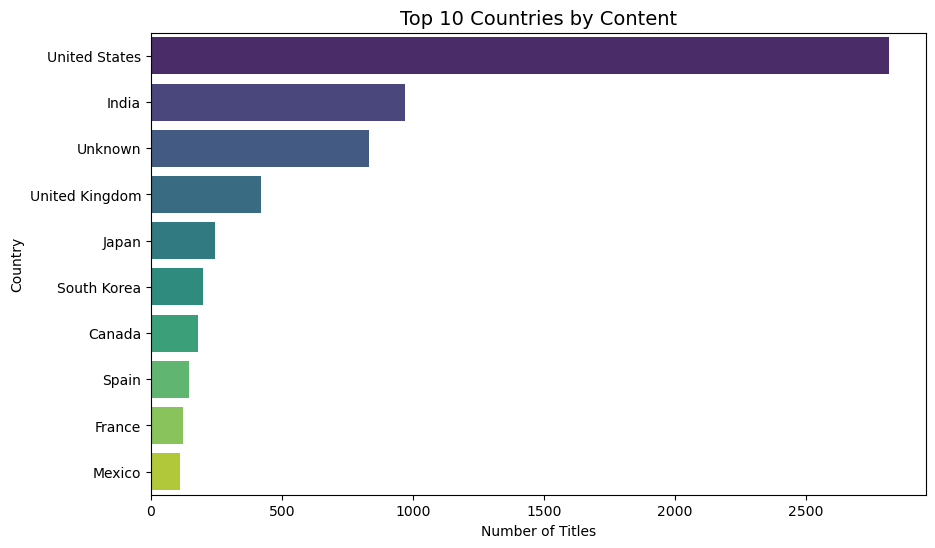

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns


country_content = data['country'].value_counts().head(10)


plt.figure(figsize=(10, 6))
sns.barplot(x=country_content.values, y=country_content.index, palette='viridis')
plt.title('Top 10 Countries by Content', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()


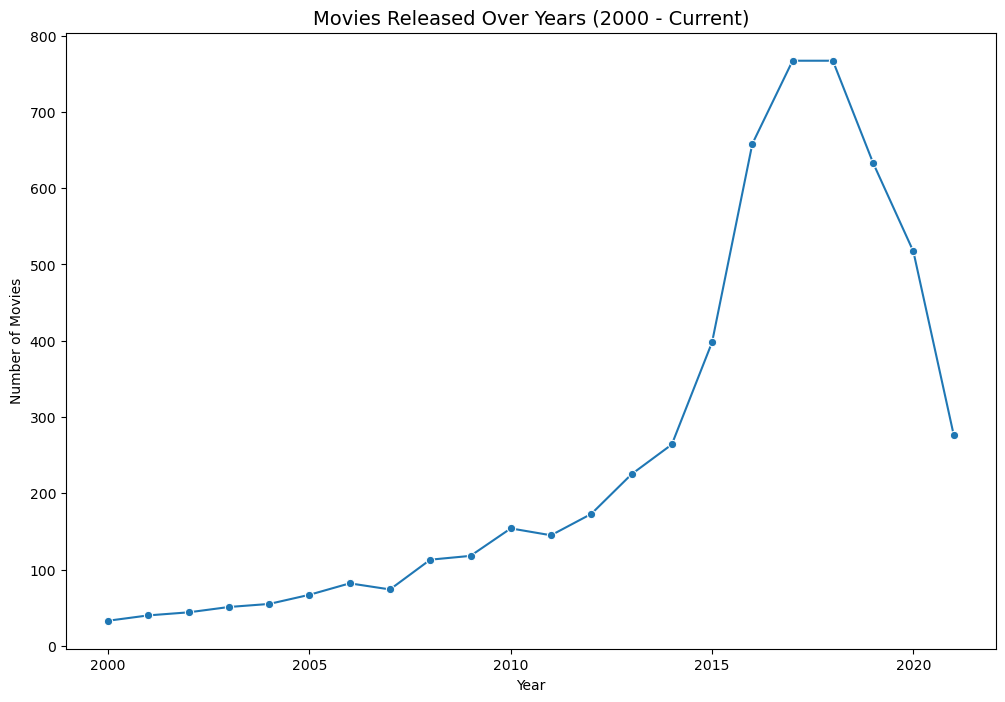

In [201]:

movies_per_year = data[data['type'] == 'Movie']
movies_per_year = movies_per_year[movies_per_year['release_year'] >= 2000]
movies_per_year = movies_per_year['release_year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 8))
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values, marker='o')
plt.title('Movies Released Over Years (2000 - Current)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

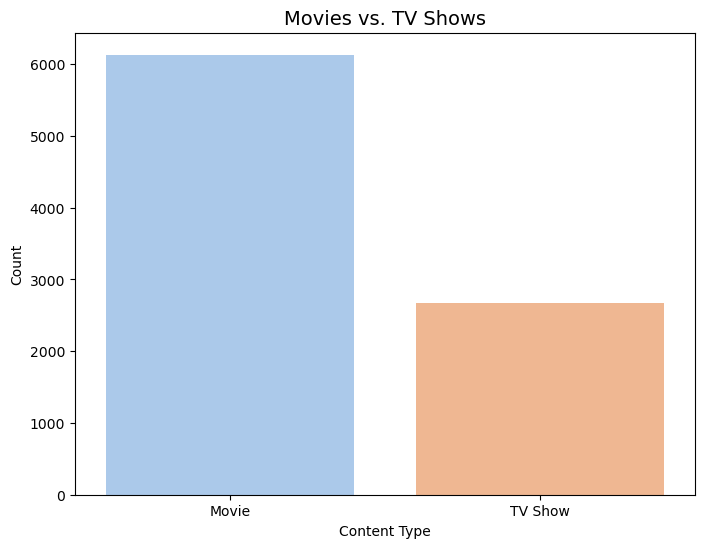

In [44]:

content_type = data['type'].value_counts()


plt.figure(figsize=(8, 6))
sns.barplot(x=content_type.index, y=content_type.values, palette='pastel')
plt.title('Movies vs. TV Shows', fontsize=14)
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()


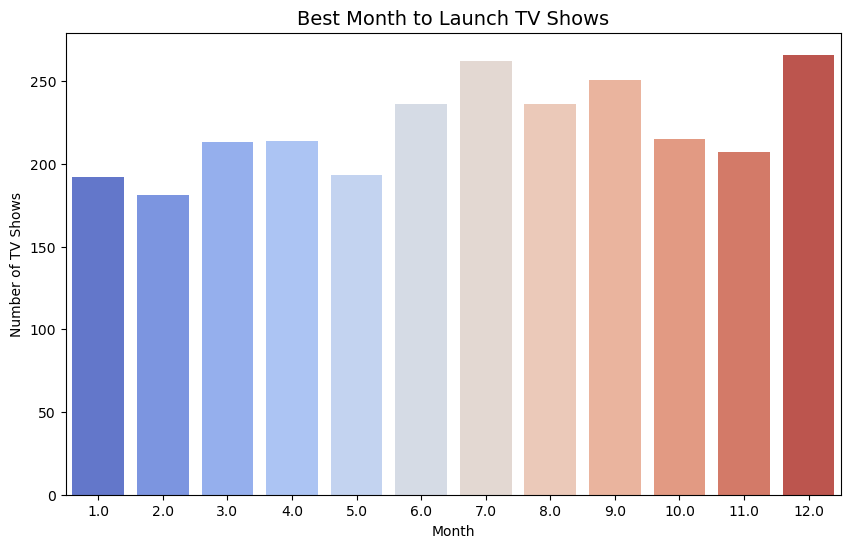

In [46]:

data['month_added'] = data['date_added'].dt.month


tv_shows_month = data[data['type'] == 'TV Show']['month_added'].value_counts().sort_index()


plt.figure(figsize=(10, 6))
sns.barplot(x=tv_shows_month.index, y=tv_shows_month.values, palette='coolwarm')
plt.title('Best Month to Launch TV Shows', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of TV Shows')
plt.show()


In [48]:
data.to_csv('data_backup.csv', index=False)


In [50]:
print(data['listed_in'].value_counts()) 


listed_in
Dramas, International Movies                          362
Documentaries                                         359
Stand-Up Comedy                                       334
Comedies, Dramas, International Movies                274
Dramas, Independent Movies, International Movies      252
                                                     ... 
Kids' TV, TV Action & Adventure, TV Dramas              1
TV Comedies, TV Dramas, TV Horror                       1
Children & Family Movies, Comedies, LGBTQ Movies        1
Kids' TV, Spanish-Language TV Shows, Teen TV Shows      1
Cult Movies, Dramas, Thrillers                          1
Name: count, Length: 514, dtype: int64


In [52]:



data_genres = data.assign(genre=data['listed_in'].str.split(',')).explode('genre')


data_genres['genre'] = data_genres['genre'].str.strip()


genre_year = data_genres.groupby(['release_year', 'genre']).size().reset_index(name='count')


recent_years = genre_year[genre_year['release_year'] >= (genre_year['release_year'].max() - 10)]


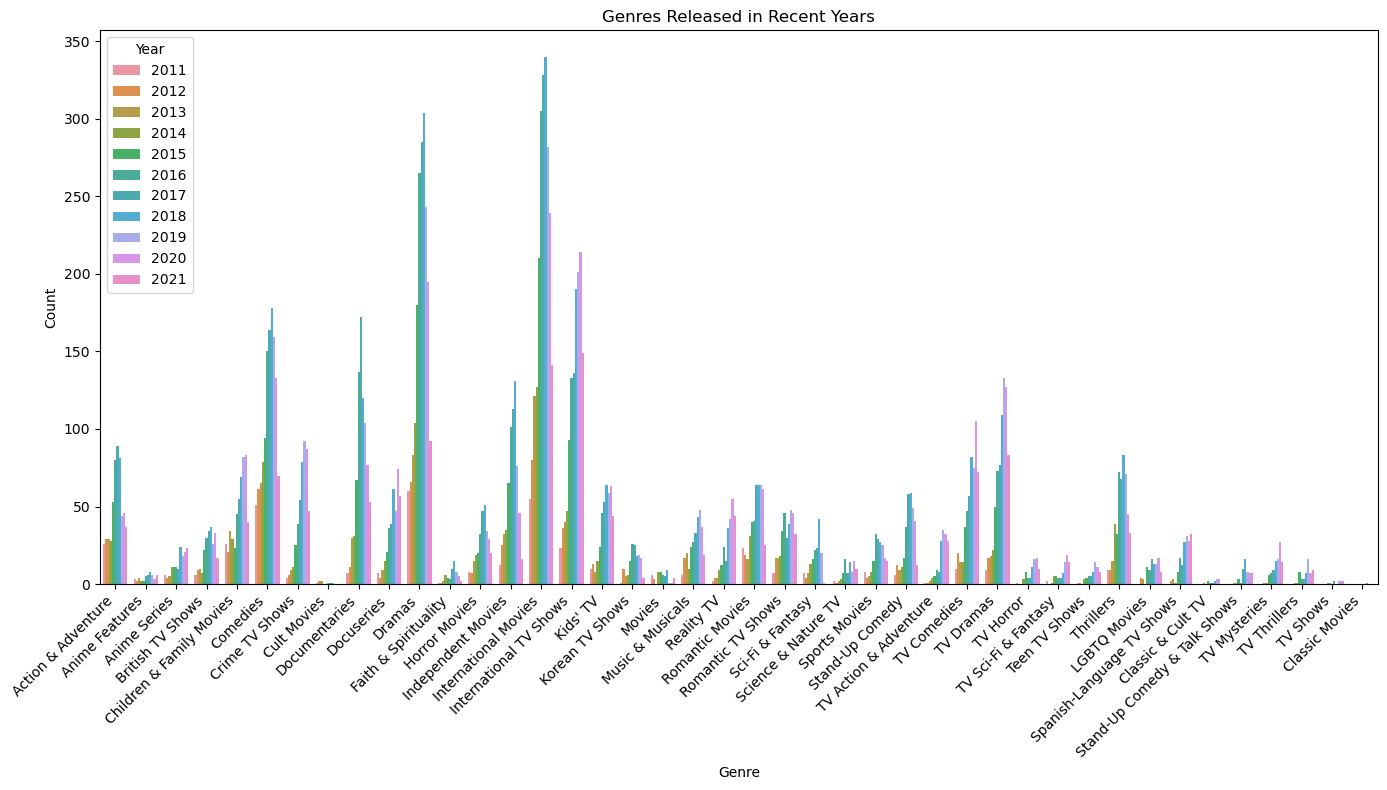

In [54]:

plt.figure(figsize=(14, 8))
sns.barplot(data=recent_years, x='genre', y='count', hue='release_year', dodge=True)
plt.xticks(rotation=45, ha='right')
plt.title("Genres Released in Recent Years")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.legend(title="Year")
plt.tight_layout()
plt.show()


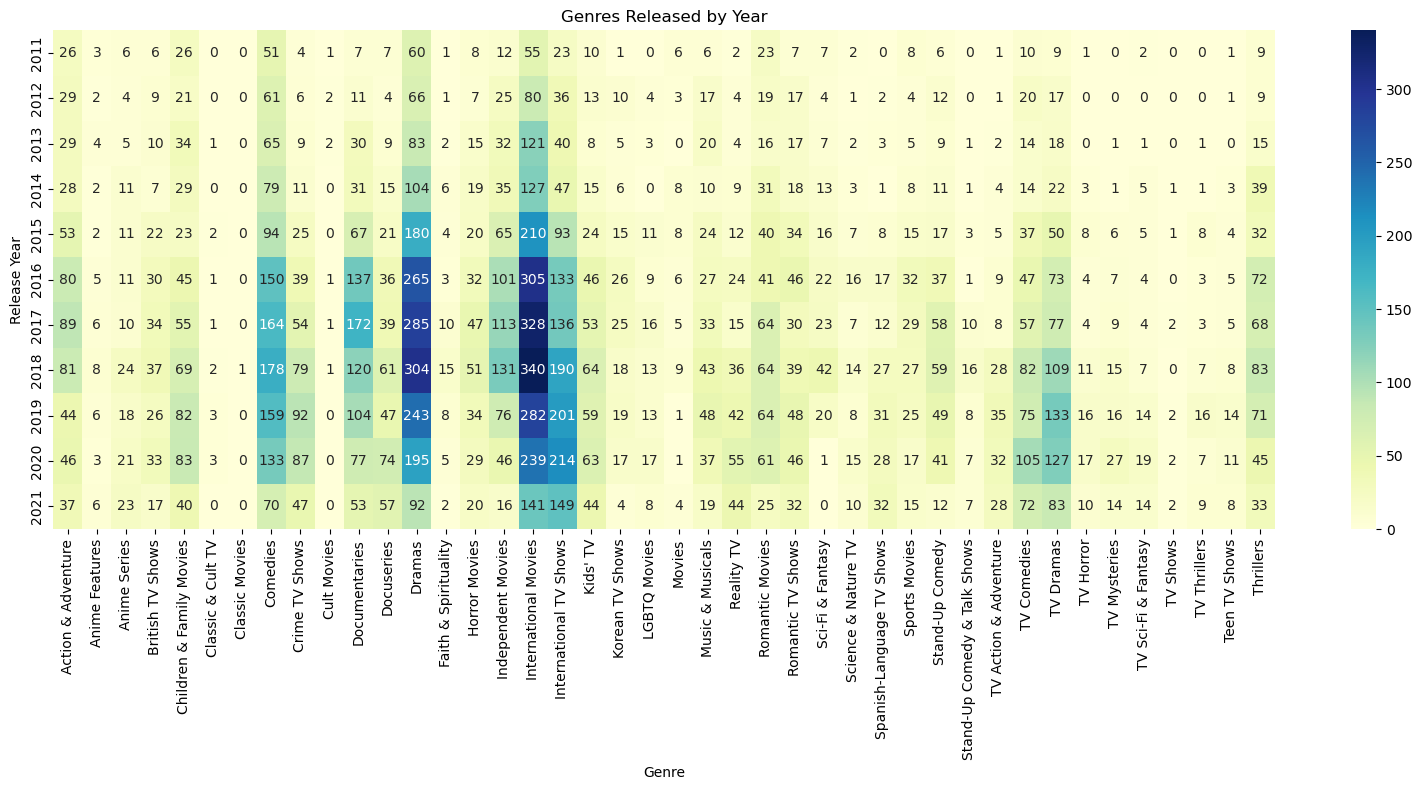

In [56]:

heatmap_data = recent_years.pivot(index='release_year', columns='genre', values='count').fillna(0)


plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Genres Released by Year")
plt.xlabel("Genre")
plt.ylabel("Release Year")
plt.tight_layout()
plt.show()


In [58]:
print(data['listed_in'].value_counts().head(10))


listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


In [60]:
print(data['country'].value_counts().head(5))


country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
Name: count, dtype: int64


In [62]:
print(data['type'].value_counts())


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [64]:

print("Unique values in 'listed_in':", data['listed_in'].nunique())
print("Value counts in 'listed_in':")
print(data['listed_in'].value_counts())


print("Unique values in 'rating':", data['rating'].nunique())
print("Value counts in 'rating':")
print(data['rating'].value_counts())

print("Unique values in 'country':", data['country'].nunique())
print("Value counts in 'country':")
print(data['country'].value_counts())


Unique values in 'listed_in': 514
Value counts in 'listed_in':
listed_in
Dramas, International Movies                          362
Documentaries                                         359
Stand-Up Comedy                                       334
Comedies, Dramas, International Movies                274
Dramas, Independent Movies, International Movies      252
                                                     ... 
Kids' TV, TV Action & Adventure, TV Dramas              1
TV Comedies, TV Dramas, TV Horror                       1
Children & Family Movies, Comedies, LGBTQ Movies        1
Kids' TV, Spanish-Language TV Shows, Teen TV Shows      1
Cult Movies, Dramas, Thrillers                          1
Name: count, Length: 514, dtype: int64
Unique values in 'rating': 17
Value counts in 'rating':
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41


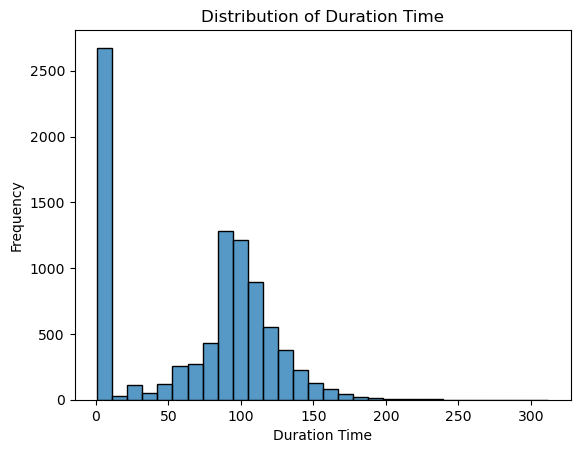

In [68]:

sns.histplot(data['duration_time'].dropna(), kde=False, bins=30)
plt.title("Distribution of Duration Time")
plt.xlabel("Duration Time")
plt.ylabel("Frequency")
plt.show()

In [70]:
print(data.isnull().sum())

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
duration_time     3
duration_type     3
month_added      10
dtype: int64


In [78]:
# Value counts of genres
genre_counts = data['listed_in'].value_counts()

# Show the top 10 genres
print(genre_counts.head(10))

# You can also calculate the percentage of each genre's appearance
genre_percentage = (genre_counts / genre_counts.sum()) * 100
print(genre_percentage.head(10))


listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64
listed_in
Dramas, International Movies                        4.110367
Documentaries                                       4.076303
Stand-Up Comedy                                     3.792438
Comedies, Dramas, International Movies              3.111162
Dramas, Independent Movies, International Movies    2.861360
Kids' TV                                            2.498013
Children & Family Movies    

In [80]:
# Calculate the number of genres per title (split by commas if multiple genres)
data['num_genres'] = data['listed_in'].apply(lambda x: len(x.split(',')))

# Calculate the average number of genres per title
average_genres_per_title = data['num_genres'].mean()
print(f"Average Number of Genres per Title: {average_genres_per_title}")


Average Number of Genres per Title: 2.194050187350971


In [82]:
# Group by release year and genre, then get the count
genre_by_year = data.groupby(['release_year', 'listed_in']).size().unstack(fill_value=0)

# Show the genre distribution for recent years (let's say the last 5 years)
recent_years = genre_by_year.loc[genre_by_year.index.astype(int) >= 2018]
print(recent_years)

# Calculate the percentage of genres in recent years
recent_year_percentage = (recent_years / recent_years.sum(axis=1).values[:, None]) * 100
print(recent_year_percentage)


listed_in     Action & Adventure  Action & Adventure, Anime Features  \
release_year                                                           
2018                          12                                   0   
2019                           8                                   0   
2020                          11                                   0   
2021                           5                                   1   

listed_in     Action & Adventure, Anime Features, Children & Family Movies  \
release_year                                                                 
2018                                                          1              
2019                                                          2              
2020                                                          0              
2021                                                          1              

listed_in     Action & Adventure, Anime Features, Classic Movies  \
release_year                  

In [86]:
# Group genres into broader categories
def map_genres(genre):
    if 'Action' in genre:
        return 'Action'
    elif 'Drama' in genre:
        return 'Drama'
    elif 'Comedy' in genre:
        return 'Comedy'
    elif 'Horror' in genre:
        return 'Horror'
    elif 'Documentary' in genre:
        return 'Documentary'
    else:
        return 'Other'

data['broad_genre'] = data['listed_in'].apply(map_genres)

# Verify the new column
print(data['broad_genre'].value_counts())


broad_genre
Other     4112
Drama     2903
Action    1027
Comedy     399
Horror     366
Name: count, dtype: int64


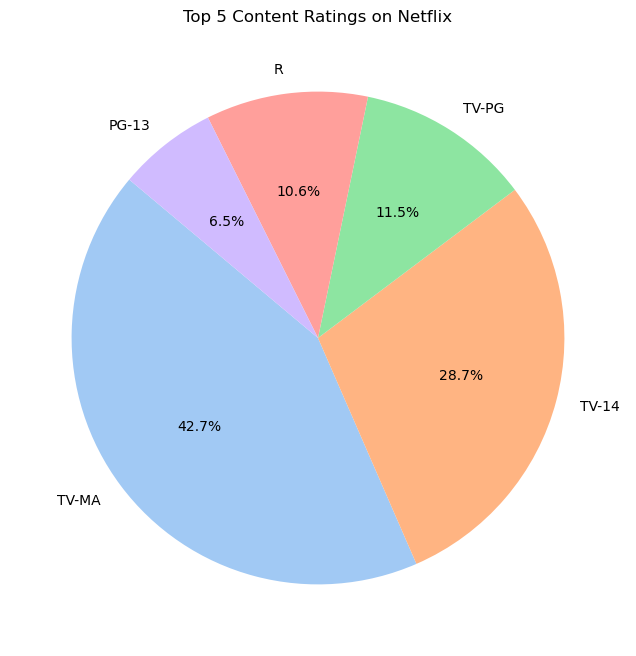

In [94]:
# Pie chart for content ratings
rating_counts = data['rating'].value_counts().head(5)

plt.figure(figsize=(8, 8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Top 5 Content Ratings on Netflix')
plt.show()


In [108]:

# Assuming 'release_year' is already numeric and 'data' is your DataFrame
recent_data = data[data['release_year'] >= (pd.Timestamp.now().year - 15)]

print(recent_data.head())


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

In [116]:
import pandas as pd



# Splitting multi-genre entries
data['listed_in'] = data['listed_in'].str.split(', ')

# Explode genres into separate rows for counting
exploded_data = data.explode('listed_in')

# Get the top 10 genres
top_genres = exploded_data['listed_in'].value_counts().head(10).index

# Condense genres
data['condensed_genre'] = data['listed_in'].apply(
    lambda genres: ', '.join([genre for genre in genres if genre in top_genres]) or 'Others'
)

# Exploded Data (to get one row per genre)
exploded_data_condensed = data.explode('condensed_genre')

# Checking the result
print(exploded_data_condensed[['title', 'condensed_genre']].head())


                   title                    condensed_genre
0   Dick Johnson Is Dead                      Documentaries
1          Blood & Water  International TV Shows, TV Dramas
2              Ganglands             International TV Shows
3  Jailbirds New Orleans                             Others
4           Kota Factory             International TV Shows


In [126]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_time,duration_type,month_added,num_genres,broad_genre,condensed_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",90.0,min,9.0,1,Other,Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",2.0,Seasons,9.0,3,Drama,"International TV Shows, TV Dramas"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,1.0,Season,9.0,3,Action,International TV Shows
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",1.0,Season,9.0,2,Other,Others
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,2.0,Seasons,9.0,3,Other,International TV Shows


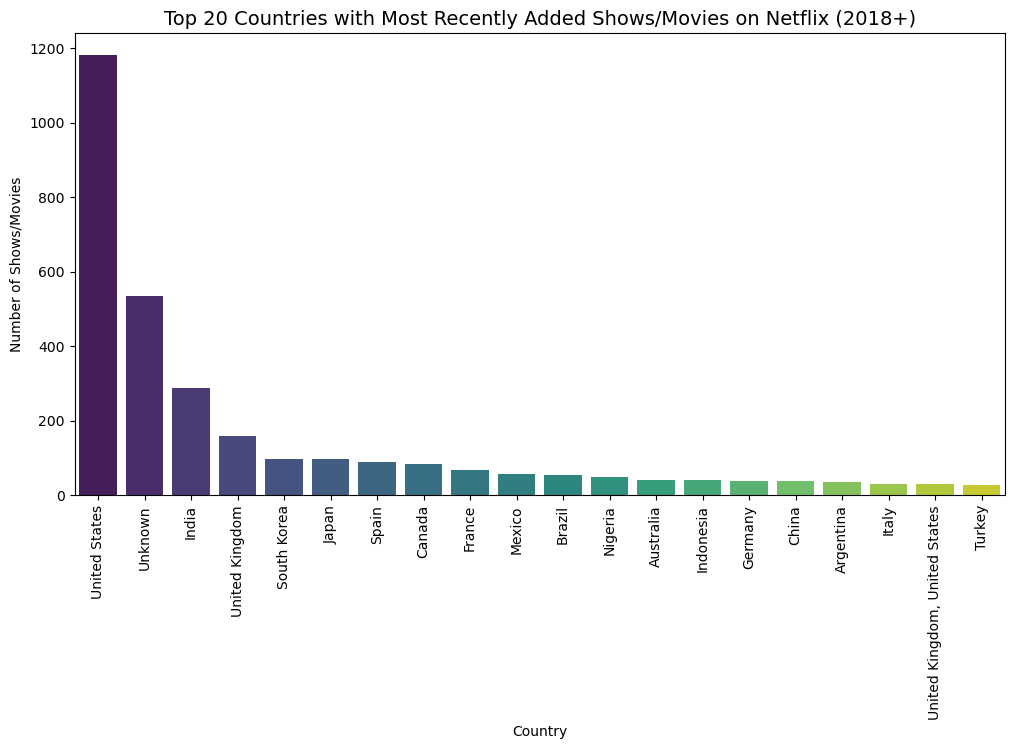

In [128]:

# Filter data for recent years (for example, past 5 years)
recent_data = data[data['release_year'] >= 2018]

# Group by country and count the number of shows/movies added
country_counts = recent_data['country'].value_counts().head(20)  # Limiting to top 20 countries

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Number of Shows/Movies')
plt.title('Top 20 Countries with Most Recently Added Shows/Movies on Netflix (2018+)', fontsize=14)
plt.show()


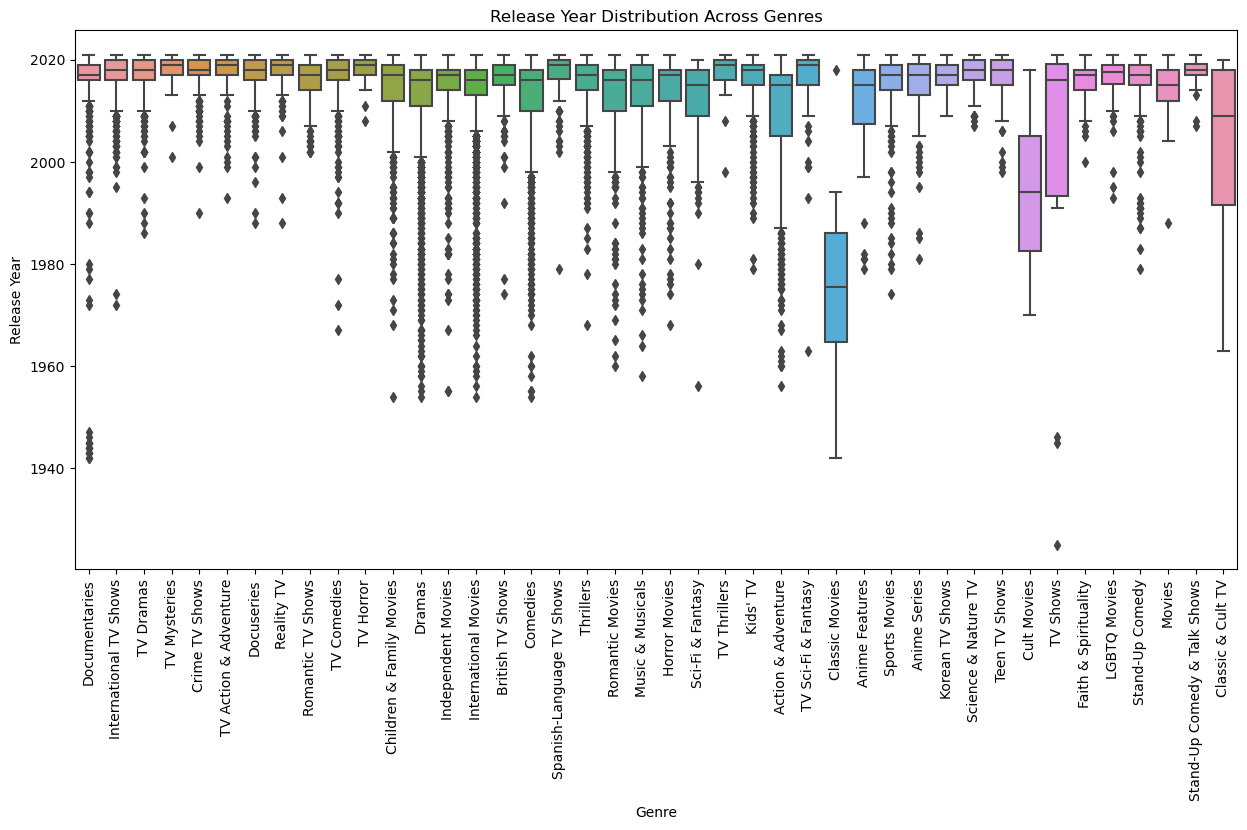

In [132]:
# First, split the genres (if they are stored as a list) and then explode the 'listed_in' column.
data['listed_in'] = data['listed_in'].apply(lambda x: x.split(', ') if isinstance(x, str) else x)

# Now explode the list so each genre has its own row.
unnested_data = data.explode('listed_in')

# Boxplot for release year by genre
plt.figure(figsize=(15, 7))
sns.boxplot(x='listed_in', y='release_year', data=unnested_data)
plt.xticks(rotation=90)
plt.title('Release Year Distribution Across Genres')
plt.xlabel('Genre')
plt.ylabel('Release Year')
plt.show()


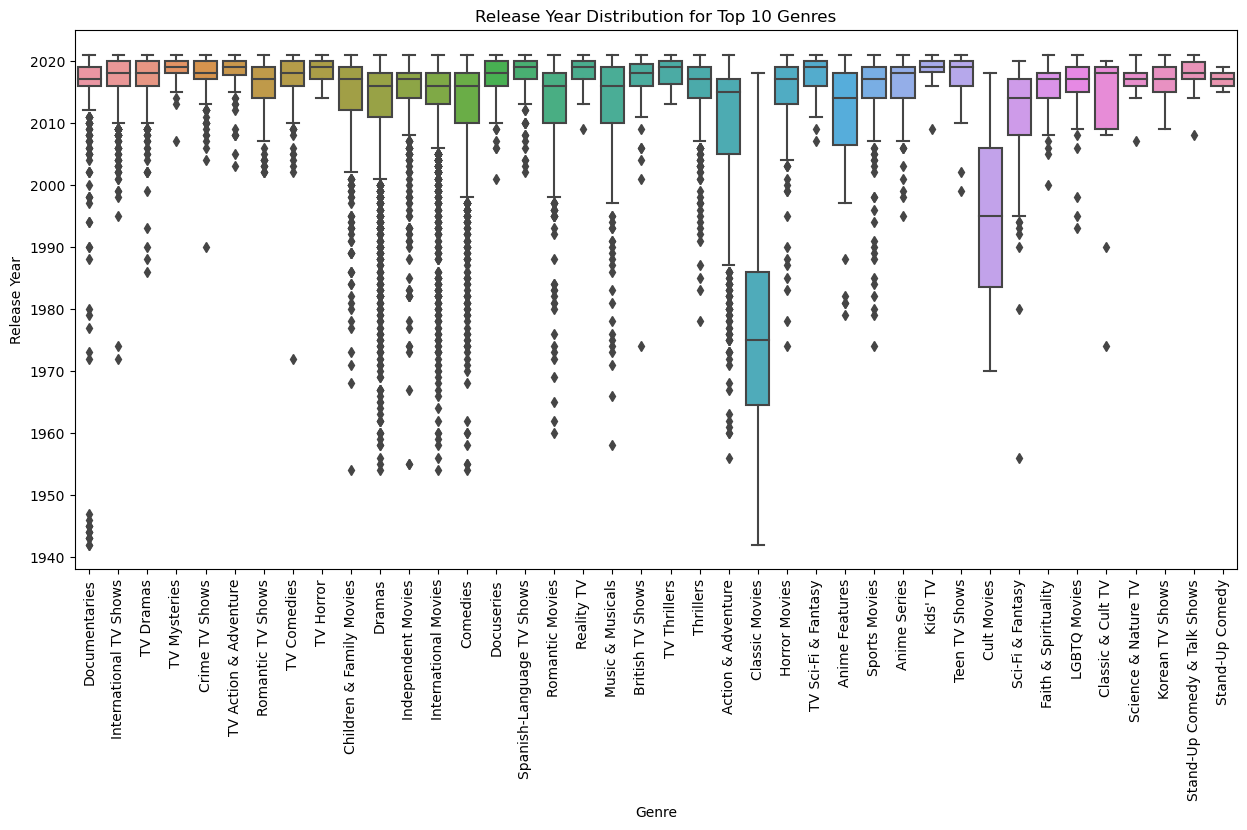

In [134]:
# Get the most frequent genres
genre_counts = data['listed_in'].explode().value_counts()

# Select top 10 most frequent genres
top_genres = genre_counts.head(10).index

# Filter data to include only top 10 genres
filtered_data = data[data['listed_in'].apply(lambda x: any(genre in top_genres for genre in x))]

# Explode the listed_in column again for boxplot
unnested_data = filtered_data.explode('listed_in')

# Boxplot for release year by top genres
plt.figure(figsize=(15, 7))
sns.boxplot(x='listed_in', y='release_year', data=unnested_data)
plt.xticks(rotation=90)
plt.title('Release Year Distribution for Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Release Year')
plt.show()


In [150]:
import pandas as pd

# Load the dataset from the 'netflix.csv' file
df = pd.read_csv('netflix.csv')  # Ensure the file path is correct

# Get the total number of unique genres from the 'listed_in' column
total_genres = df['listed_in'].nunique()

# Display the total number of unique genres
print("Total number of unique genres:", total_genres)
unique_countries = df['country'].nunique()

# Get the total number of null values in the 'listed_in' and 'country' columns
null_values = df[['listed_in', 'country']].isnull().sum()

# Display the results
print("Total number of unique countries:", unique_countries)
print("\nTotal null values in 'listed_in' and 'country' columns:\n", null_values)


Total number of unique genres: 514
Total number of unique countries: 748

Total null values in 'listed_in' and 'country' columns:
 listed_in      0
country      831
dtype: int64


In [152]:
missing_values = df.isnull().sum()

# Display the missing values per column
print("Missing values per column:\n", missing_values)

Missing values per column:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [156]:
# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().mean() * 100

# Display the missing percentage for each column
print(missing_percentage)


show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [177]:

import pandas as pd

# Load your dataset
data = pd.read_csv("netflix.csv")

# Process 'duration' for numerical values
def extract_duration(duration):
    if pd.isnull(duration):
        return None
    elif 'min' in duration:
        return int(duration.split()[0])
    elif 'Season' in duration:
        return None  # Seasons aren't continuous values for duration

data['duration_minutes'] = data['duration'].apply(extract_duration)

# Descriptive statistics for continuous variables
continuous_columns = ['release_year', 'duration_minutes']
continuous_summary = data[continuous_columns].describe().transpose()

# Descriptive statistics for categorical variables
categorical_columns = ['type', 'director', 'cast', 'country', 'rating', 'listed_in']
categorical_summary = {
    col: {
        "Count": data[col].notnull().sum(),
        "Unique": data[col].nunique(),
        "Top": data[col].mode()[0] if not data[col].mode().empty else None,
        "Freq": data[col].value_counts().iloc[0] if not data[col].value_counts().empty else None,
    }
    for col in categorical_columns
}

# Display the results
print("Continuous Variables Summary:")
print(continuous_summary)

print("\nCategorical Variables Summary:")
for col, summary in categorical_summary.items():
    print(f"\nColumn: {col}")
    for key, value in summary.items():
        print(f"  {key}: {value}")



Continuous Variables Summary:
                   count         mean        std     min     25%     50%  \
release_year      8807.0  2014.180198   8.819312  1925.0  2013.0  2017.0   
duration_minutes  6128.0    99.577187  28.290593     3.0    87.0    98.0   

                     75%     max  
release_year      2019.0  2021.0  
duration_minutes   114.0   312.0  

Categorical Variables Summary:

Column: type
  Count: 8807
  Unique: 2
  Top: Movie
  Freq: 6131

Column: director
  Count: 6173
  Unique: 4528
  Top: Rajiv Chilaka
  Freq: 19

Column: cast
  Count: 7982
  Unique: 7692
  Top: David Attenborough
  Freq: 19

Column: country
  Count: 7976
  Unique: 748
  Top: United States
  Freq: 2818

Column: rating
  Count: 8803
  Unique: 17
  Top: TV-MA
  Freq: 3207

Column: listed_in
  Count: 8807
  Unique: 514
  Top: Dramas, International Movies
  Freq: 362


In [179]:
# Top 10 countries by frequency
top_countries = data['country'].value_counts().head(10)

# Top 10 genres ('listed_in') by frequency
# Genres are comma-separated, so we need to split them and count each genre
genre_series = data['listed_in'].dropna().str.split(', ')
all_genres = genre_series.explode()
top_genres = all_genres.value_counts().head(10)

# Display the results
print("Top 10 Countries:")
print(top_countries)

print("\nTop 10 Genres:")
print(top_genres)


Top 10 Countries:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [181]:
# Define a mapping of broad categories to keywords
genre_mapping = {
    'Comedies': ['Comedy', 'Stand-Up'],
    'Dramas': ['Drama', 'Dramatic'],
    'Action & Adventure': ['Action', 'Adventure'],
    'Documentaries': ['Documentary', 'Docuseries'],
    'Horror': ['Horror', 'Scary', 'Thriller'],
    'Romance': ['Romantic', 'Romance'],
    'Kids & Family': ['Kids', 'Children', 'Family'],
    'Sci-Fi & Fantasy': ['Sci-Fi', 'Science Fiction', 'Fantasy'],
    'Mysteries': ['Mystery', 'Crime'],
    'Music & Musicals': ['Music', 'Musical'],
    'Sports': ['Sports', 'Athletic'],
    'Reality': ['Reality'],
    'International': ['International', 'Foreign'],
}

# Function to categorize each entry
def categorize_genre(listed_in):
    if pd.isnull(listed_in):
        return None
    for category, keywords in genre_mapping.items():
        if any(keyword in listed_in for keyword in keywords):
            return category
    return 'Other'

# Apply categorization to 'listed_in'
data['broad_genre'] = data['listed_in'].apply(categorize_genre)

# Count the occurrences of each broad genre
broad_genre_counts = data['broad_genre'].value_counts()

# Display the results
print("Broad Genre Counts:")
print(broad_genre_counts)


Broad Genre Counts:
broad_genre
Dramas                3190
Kids & Family          931
Other                  747
Action & Adventure     740
International          598
Horror                 571
Romance                536
Comedies               399
Documentaries          387
Music & Musicals       218
Reality                196
Mysteries              139
Sports                 129
Sci-Fi & Fantasy        26
Name: count, dtype: int64


In [183]:
df_filtered = df[df['release_year'] >= 1990]

# Get the distribution of release years
release_year_distribution = df_filtered['release_year'].value_counts().sort_index()

# Print the distribution
print("Release Year Distribution (1990 to latest):")
print(release_year_distribution)

Release Year Distribution (1990 to latest):
release_year
1990      22
1991      17
1992      23
1993      28
1994      22
1995      25
1996      24
1997      38
1998      36
1999      39
2000      37
2001      45
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


In [189]:

df['cast'] = df['cast'].fillna('')

# Split the 'cast' column into a list of actors (if multiple actors exist)
df['cast_list'] = df['cast'].apply(lambda x: x.split(',') if x else [])

# Flatten the list of actors and count appearances
actors = df['cast_list'].explode().value_counts().head(10)

# Print the top 10 actors with the most appearances
print("Top 10 actors with the most appearances:")
print(actors)


Top 10 actors with the most appearances:
cast_list
 Anupam Kher         39
 Rupa Bhimani        31
 Takahiro Sakurai    30
 Julie Tejwani       28
 Om Puri             27
 Rajesh Kava         26
Shah Rukh Khan       26
 Yuki Kaji           25
 Paresh Rawal        25
 Andrea Libman       25
Name: count, dtype: int64


In [191]:
df['director'] = df['director'].fillna('')

# Split the 'director' column into a list (if multiple directors exist)
df['director_list'] = df['director'].apply(lambda x: x.split(',') if x else [])

# Flatten the list of directors and count appearances
directors = df['director_list'].explode().value_counts().head(10)

# Print the top 10 directors with the most appearances
print("Top 10 directors with the most appearances:")
print(directors)

Top 10 directors with the most appearances:
director_list
Rajiv Chilaka          22
Raúl Campos            18
 Jan Suter             18
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Jay Chapman            12
Youssef Chahine        12
Name: count, dtype: int64


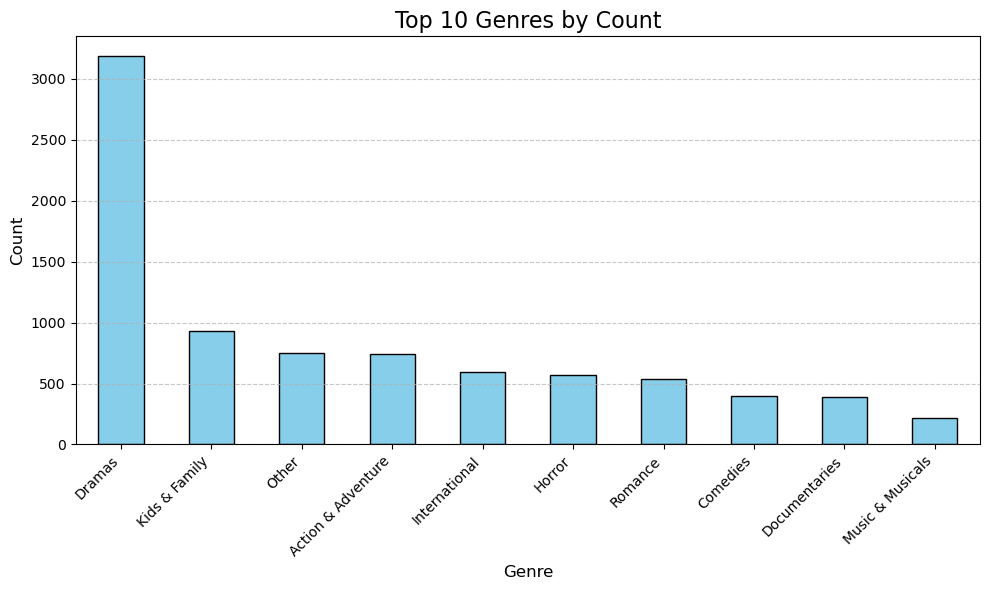

In [205]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = "netflix.csv"  # Replace with your file path
data = pd.read_csv(file_path)

# Define a mapping of broad categories to keywords
genre_mapping = {
    'Comedies': ['Comedy', 'Stand-Up'],
    'Dramas': ['Drama', 'Dramatic'],
    'Action & Adventure': ['Action', 'Adventure'],
    'Documentaries': ['Documentary', 'Docuseries'],
    'Horror': ['Horror', 'Scary', 'Thriller'],
    'Romance': ['Romantic', 'Romance'],
    'Kids & Family': ['Kids', 'Children', 'Family'],
    'Sci-Fi & Fantasy': ['Sci-Fi', 'Science Fiction', 'Fantasy'],
    'Mysteries': ['Mystery', 'Crime'],
    'Music & Musicals': ['Music', 'Musical'],
    'Sports': ['Sports', 'Athletic'],
    'Reality': ['Reality'],
    'International': ['International', 'Foreign'],
}

# Function to categorize each entry
def categorize_genre(listed_in):
    if pd.isnull(listed_in):
        return None
    for category, keywords in genre_mapping.items():
        if any(keyword in listed_in for keyword in keywords):
            return category
    return 'Other'

# Apply categorization to 'listed_in'
data['broad_genre'] = data['listed_in'].apply(categorize_genre)

# Count the occurrences of each broad genre
broad_genre_counts = data['broad_genre'].value_counts()

# Filter top 10 genres
top_10_genres = broad_genre_counts.head(10)

# Plotting the top 10 genres
plt.figure(figsize=(10, 6))
top_10_genres.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Genres by Count', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


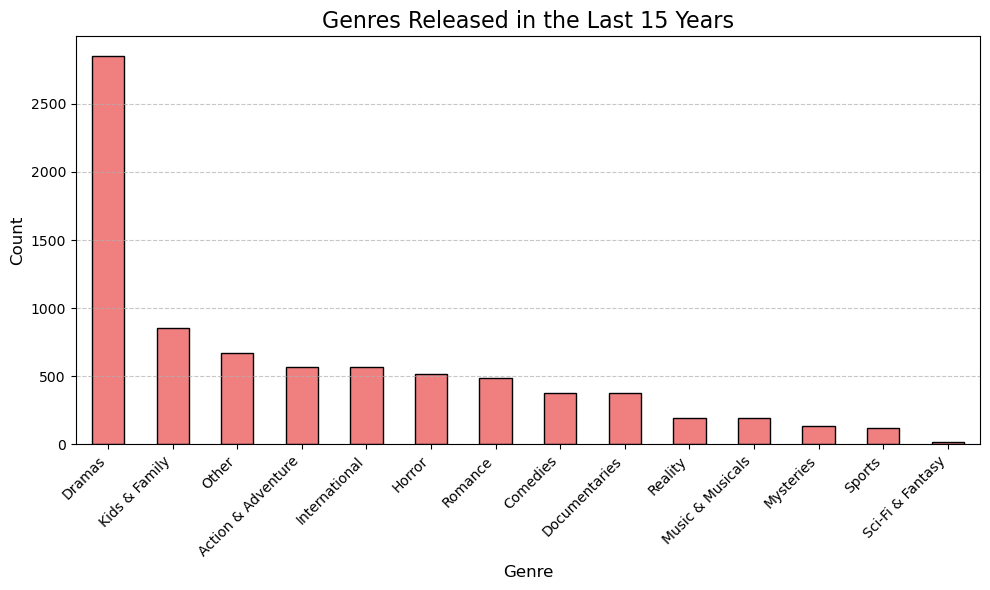

In [207]:
import numpy as np

# Filter data for the last 15 years (from the most recent release year)
current_year = data['release_year'].max()
recent_data = data[data['release_year'] >= (current_year - 15)]

# Count the occurrences of each genre for the recent years
recent_genre_counts = recent_data['broad_genre'].value_counts()

# Plotting the genre distribution for the last 15 years
plt.figure(figsize=(10, 6))
recent_genre_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Genres Released in the Last 15 Years', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()
